Cluster 1	Low app usage / low engagement
Cluster 2	Regular users with moderate engagement
CHighly engaged users
Users showing higher symptom/stress scores

In [35]:
import pandas as pd

In [36]:
df = pd.read_csv("digital_diet_mental_health.csv")

In [37]:
df.shape

(2000, 25)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           2000 non-null   str    
 1   age                               2000 non-null   int64  
 2   gender                            2000 non-null   str    
 3   daily_screen_time_hours           2000 non-null   float64
 4   phone_usage_hours                 2000 non-null   float64
 5   laptop_usage_hours                2000 non-null   float64
 6   tablet_usage_hours                2000 non-null   float64
 7   tv_usage_hours                    2000 non-null   float64
 8   social_media_hours                2000 non-null   float64
 9   work_related_hours                2000 non-null   float64
 10  entertainment_hours               2000 non-null   float64
 11  gaming_hours                      2000 non-null   float64
 12  sleep_duration_ho

In [39]:
df.describe()

,age,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,entertainment_hours,gaming_hours,...,mood_rating,stress_level,physical_activity_hours_per_week,mental_health_score,uses_wellness_apps,eats_healthy,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.0000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.00000,2000.000000
mean,38.805500,6.025600,3.023700,1.999950,0.995650,1.503700,2.039200,2.010250,2.46735,1.2795,...,5.591000,5.541500,3.087150,49.650500,0.387500,0.507500,148.07970,9.887500,10.04900,10.753750
std,14.929203,1.974123,1.449399,0.997949,0.492714,0.959003,1.133435,1.116111,1.23686,0.8945,...,2.899814,2.885731,1.885258,17.546717,0.487301,0.500069,48.86066,6.027853,6.05334,7.340269
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000,...,1.000000,1.000000,0.000000,20.000000,0.000000,0.000000,0.80000,0.000000,0.00000,0.000000
25%,26.000000,4.700000,2.000000,1.300000,0.600000,0.800000,1.200000,1.200000,1.60000,0.6000,...,3.000000,3.000000,1.600000,35.000000,0.000000,0.000000,113.90000,5.000000,5.00000,4.900000
50%,39.000000,6.000000,3.000000,2.000000,1.000000,1.500000,2.000000,2.000000,2.40000,1.2000,...,6.000000,6.000000,3.000000,49.000000,0.000000,1.000000,147.45000,10.000000,10.00000,10.400000
75%,51.000000,7.325000,4.000000,2.700000,1.300000,2.200000,2.800000,2.800000,3.30000,1.9000,...,8.000000,8.000000,4.400000,64.250000,1.000000,1.000000,180.70000,15.000000,15.00000,15.800000
max,64.000000,13.300000,8.400000,5.600000,2.500000,4.700000,5.800000,5.900000,6.80000,4.0000,...,10.000000,10.000000,9.700000,80.000000,1.000000,1.000000,364.90000,20.000000,20.00000,36.400000


In [40]:
df.duplicated().sum()


np.int64(0)

In [41]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
daily_screen_time_hours             0
phone_usage_hours                   0
laptop_usage_hours                  0
tablet_usage_hours                  0
tv_usage_hours                      0
social_media_hours                  0
work_related_hours                  0
entertainment_hours                 0
gaming_hours                        0
sleep_duration_hours                0
sleep_quality                       0
mood_rating                         0
stress_level                        0
physical_activity_hours_per_week    0
location_type                       0
mental_health_score                 0
uses_wellness_apps                  0
eats_healthy                        0
caffeine_intake_mg_per_day          0
weekly_anxiety_score                0
weekly_depression_score             0
mindfulness_minutes_per_day         0
dtype: int64

In [42]:
numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    higher_fence = Q3 + 1.5 * IQR

    df = df[
        df[col].between(lower_fence, higher_fence)
    ].reset_index(drop=True)

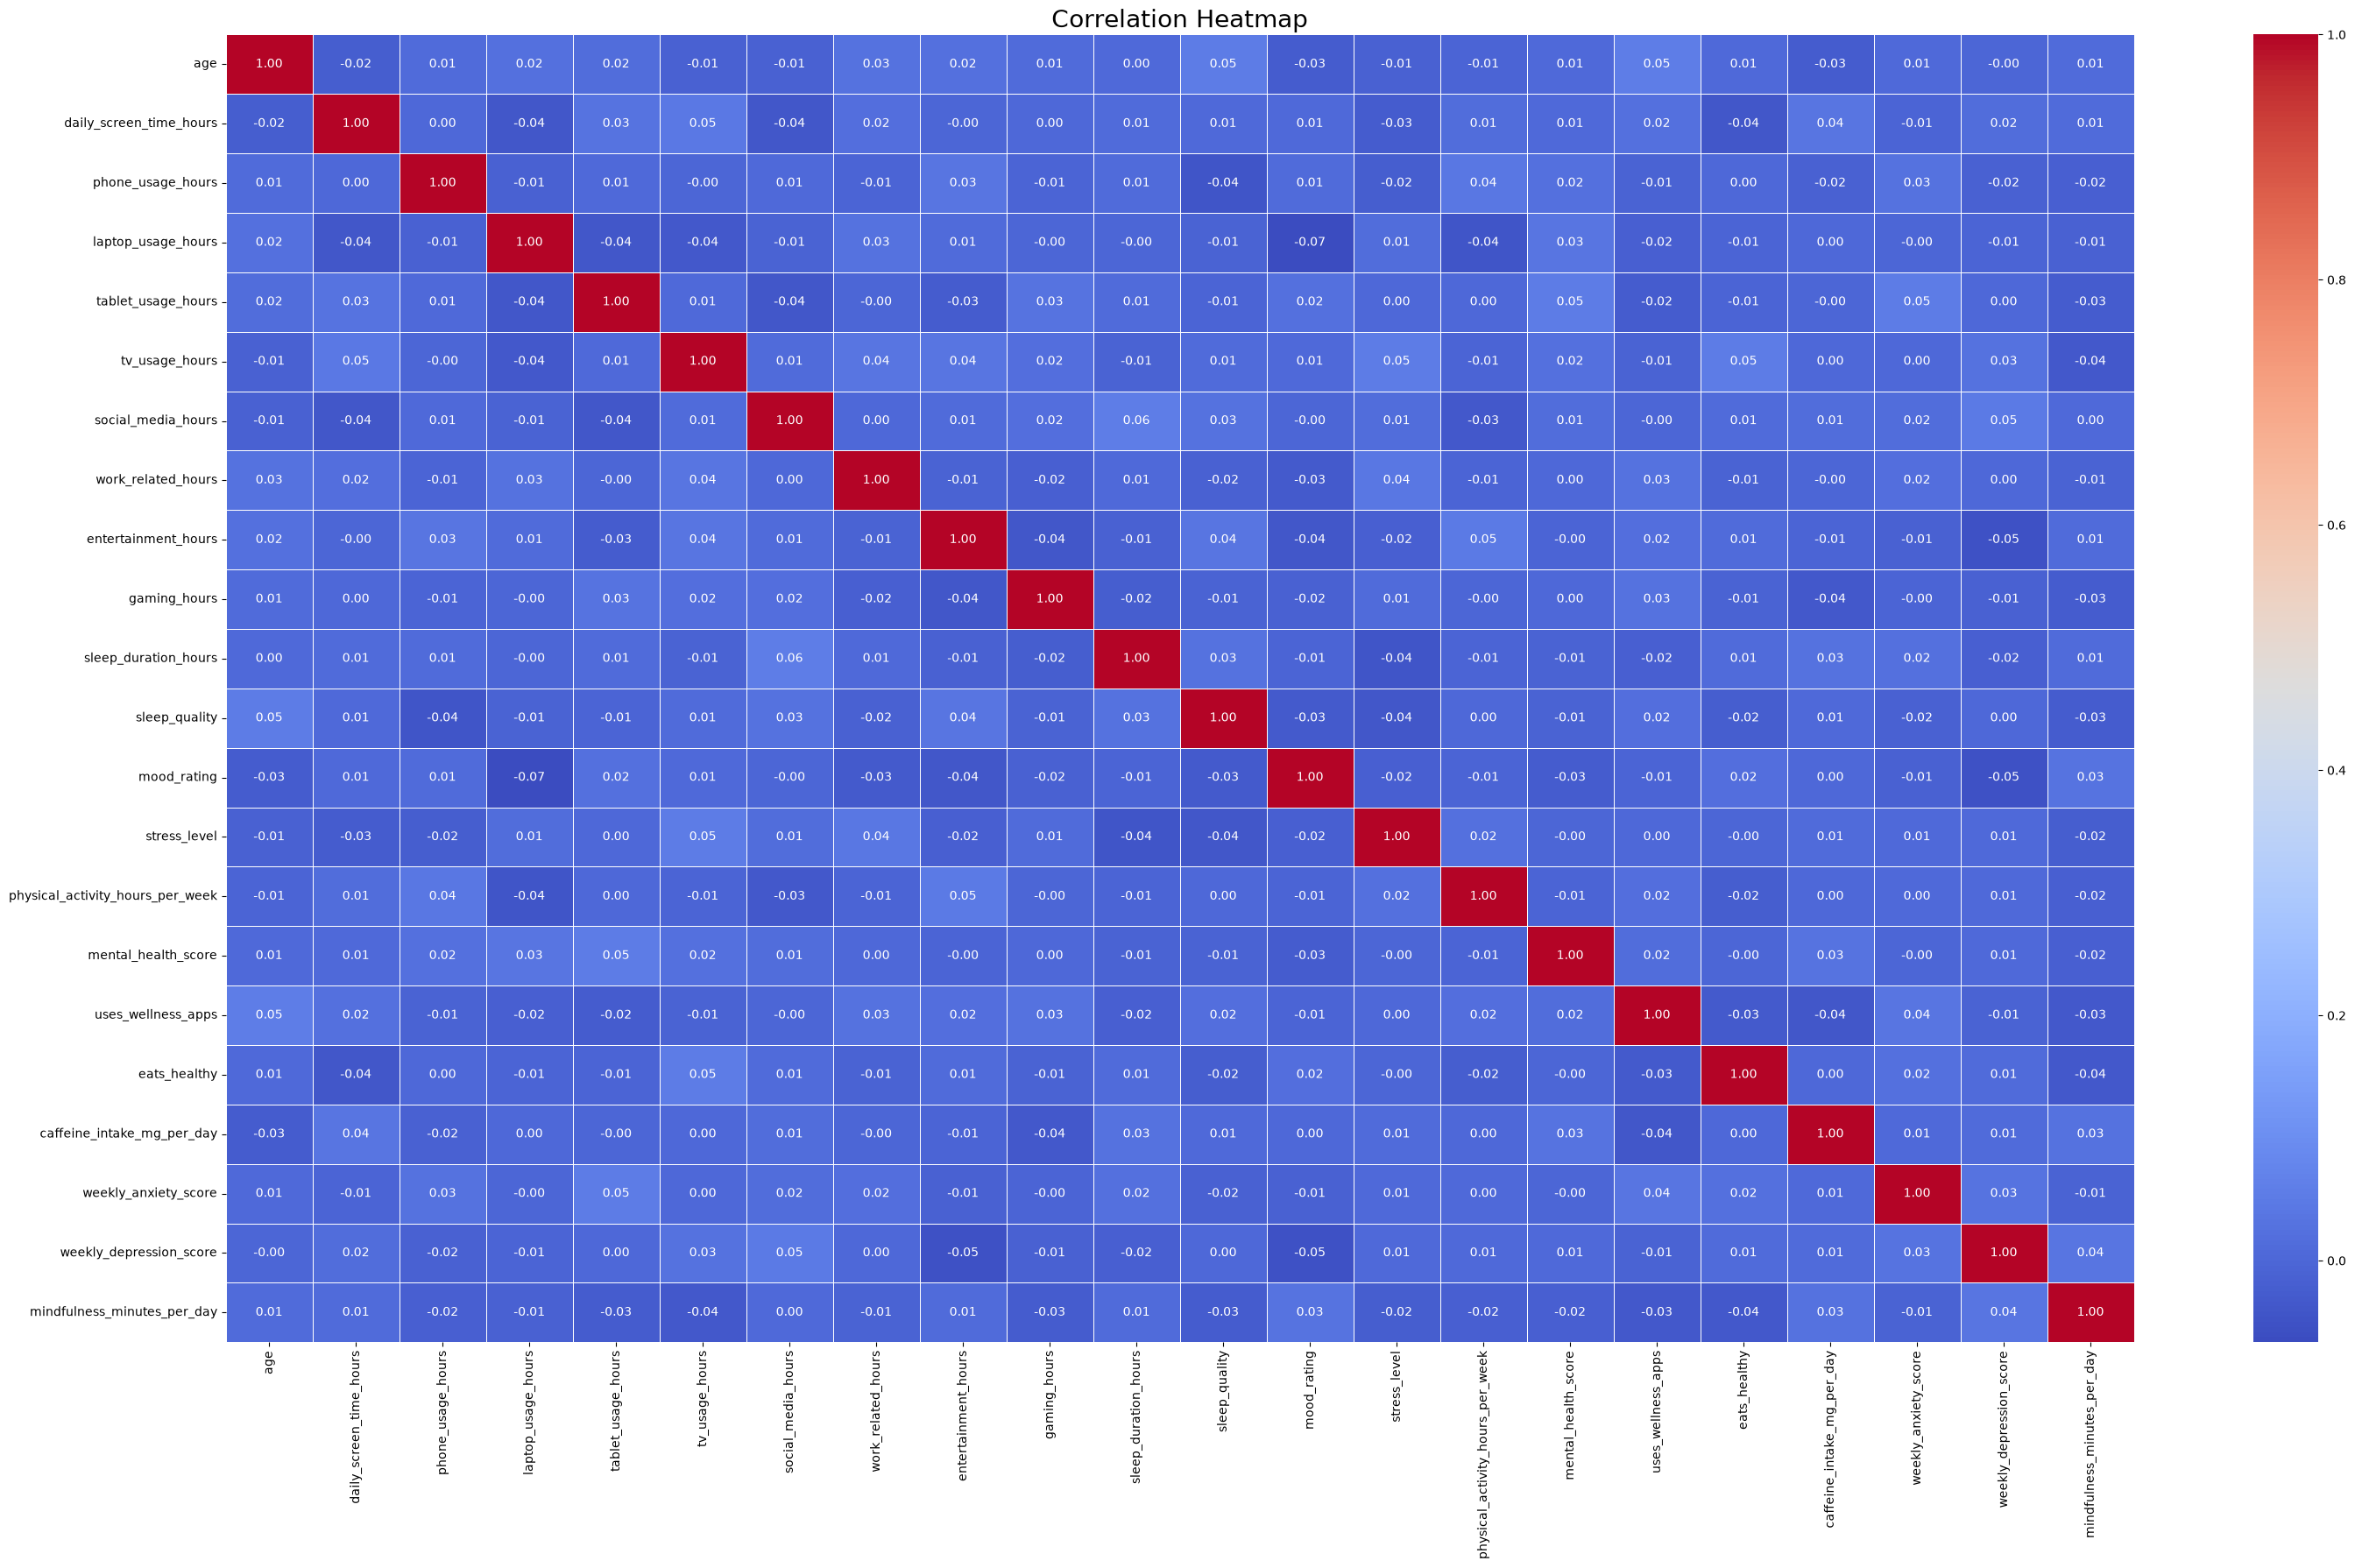

In [43]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_columns = df.select_dtypes(include="number")

# Calculate correlation
correlation = numerical_columns.corr()

# Plot heatmap
plt.figure(figsize=(30, 18))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)
plt.tight_layout()
plt.show()

In [44]:
df.dtypes

user_id                                 str
age                                   int64
gender                                  str
daily_screen_time_hours             float64
phone_usage_hours                   float64
laptop_usage_hours                  float64
tablet_usage_hours                  float64
tv_usage_hours                      float64
social_media_hours                  float64
work_related_hours                  float64
entertainment_hours                 float64
gaming_hours                        float64
sleep_duration_hours                float64
sleep_quality                         int64
mood_rating                           int64
stress_level                          int64
physical_activity_hours_per_week    float64
location_type                           str
mental_health_score                   int64
uses_wellness_apps                    int64
eats_healthy                          int64
caffeine_intake_mg_per_day          float64
weekly_anxiety_score            

In [45]:
df.drop("user_id", inplace=True, axis = 1)

In [46]:
df["gender"].unique()

<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [48]:
df = pd.get_dummies(df, columns=["gender"], dtype=int)

In [51]:
df = pd.get_dummies(df,columns=["location_type"], dtype=int)

In [52]:
df.dtypes

age                                   int64
daily_screen_time_hours             float64
phone_usage_hours                   float64
laptop_usage_hours                  float64
tablet_usage_hours                  float64
tv_usage_hours                      float64
social_media_hours                  float64
work_related_hours                  float64
entertainment_hours                 float64
gaming_hours                        float64
sleep_duration_hours                float64
sleep_quality                         int64
mood_rating                           int64
stress_level                          int64
physical_activity_hours_per_week    float64
mental_health_score                   int64
uses_wellness_apps                    int64
eats_healthy                          int64
caffeine_intake_mg_per_day          float64
weekly_anxiety_score                  int64
weekly_depression_score               int64
mindfulness_minutes_per_day         float64
gender_Female                   

In [53]:
df.head()

,age,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,entertainment_hours,gaming_hours,...,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day,gender_Female,gender_Male,gender_Other,location_type_Rural,location_type_Suburban,location_type_Urban
0,51,4.8,3.4,1.3,1.6,1.6,4.1,2.0,1.0,1.7,...,125.2,13,15,4.0,1,0,0,0,0,1
1,64,3.9,3.5,1.8,0.9,2.0,2.7,3.1,1.0,1.5,...,150.4,19,18,6.5,0,1,0,0,1,0
2,41,10.5,2.1,2.6,0.7,2.2,3.0,2.8,4.1,1.7,...,187.9,7,3,6.9,0,0,1,0,1,0
3,27,8.8,0.0,0.0,0.7,2.5,3.3,1.6,1.3,0.4,...,73.6,7,2,4.8,0,0,1,1,0,0
4,55,5.9,1.7,1.1,1.5,1.6,1.1,3.6,0.8,0.8,...,217.5,8,10,0.0,0,1,0,0,0,1


In [54]:
df.shape

(1895, 28)

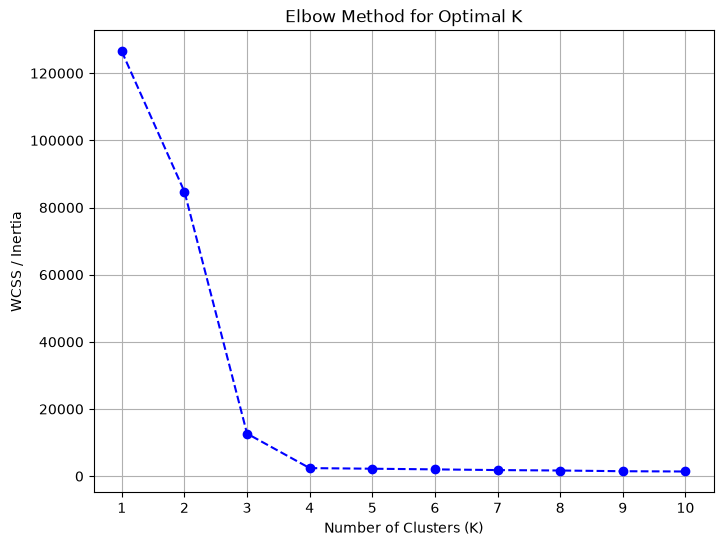

WCSS values for K=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]: [126462.70294530207, 84742.27116323149, 12679.32849341939, 2407.7217169747755, 2223.8300768838567, 2031.2306122564903, 1821.0626938561359, 1691.5447177261863, 1478.6631216863311, 1397.3462748602283]


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# --- 1. Data Generation (For demonstration) ---
# Generate a dataset with 4 clear clusters
X, y_true = make_blobs(n_samples=len(df), centers=4,
                       cluster_std=0.8, random_state=42)

# --- 2. Implement the Elbow Method ---
k_range = range(1, 11)
wcss = [] # To store WCSS (Inertia) for each K

for k in k_range:
    # Initialize K-Means with the current K
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto',
                    random_state=42, max_iter=300)
    kmeans.fit(X)

    # Get the WCSS (Inertia) value
    wcss.append(kmeans.inertia_)

# --- 3. Plot the Elbow Curve ---
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Print WCSS values for inspection
print(f"WCSS values for K={list(k_range)}: {wcss}")

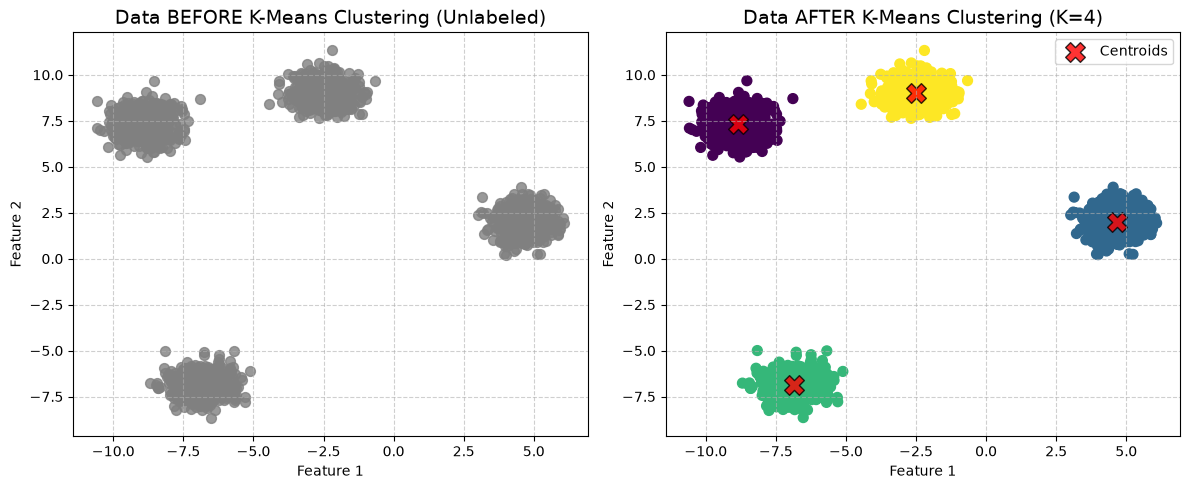


--- K-Means Results ---
The final coordinates of the 4 centroids are:
Cluster 0 Centroid: (-8.86, 7.34)
Cluster 1 Centroid: (4.68, 2.01)
Cluster 2 Centroid: (-6.87, -6.87)
Cluster 3 Centroid: (-2.51, 9.04)

Inertia (WCSS): 1354.34
Runtime: 0.008030891418457031 seconds


In [69]:
import time


import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# --- 1. Data Generation ---
# Generate a synthetic dataset with 3 clear 'blobs' (clusters)
# n_samples: total number of points
# centers: the number of clusters (K)
# random_state: for reproducibility
start_time = time.time()
n_samples = len(df)
random_seed = 42
K_clusters = 4

X, y_true = make_blobs(n_samples=len(df), centers=K_clusters,
                       cluster_std=0.60, random_state=random_seed)

# X contains the (x, y) coordinates of the data points
# y_true contains the true labels (which we ignore in K-Means, as it's unsupervised)

# --- 2. Visualization: Data BEFORE K-Means ---
plt.figure(figsize=(12, 5))

# Subplot 1: Unlabeled Data
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray', alpha=0.8)
plt.title('Data BEFORE K-Means Clustering (Unlabeled)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)

# --- 3. K-Means Implementation ---
# 1. Initialize the K-Means model
#    n_clusters=K_clusters: The 'K' value we chose (3)
#    init='k-means++': Smart initialization to speed up convergence
#    n_init='auto': Runs K-Means multiple times and returns the best one
kmeans = KMeans(n_clusters=K_clusters, init='k-means++', n_init='auto', random_state=random_seed)

# 2. Fit the model to the data (this runs the iterative assignment and update steps)
kmeans.fit(X)

# 3. Get the results
y_kmeans = kmeans.predict(X)          # The cluster labels (0, 1, or 2) for each point
centers = kmeans.cluster_centers_     # The final coordinates of the 3 centroids

end_time = time.time()
plt.subplot(1, 2, 2)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X',
            edgecolor='black', label='Centroids')

plt.title(f'Data AFTER K-Means Clustering (K={K_clusters})', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n--- K-Means Results ---")
print(f"The final coordinates of the {K_clusters} centroids are:")
for i, center in enumerate(centers):
    print(f"Cluster {i} Centroid: ({center[0]:.2f}, {center[1]:.2f})")
print(f"\nInertia (WCSS): {kmeans.inertia_:.2f}")


print("Runtime:", end_time - start_time, "seconds")

Estimated number of clusters: 0
Estimated number of noise points: 1895


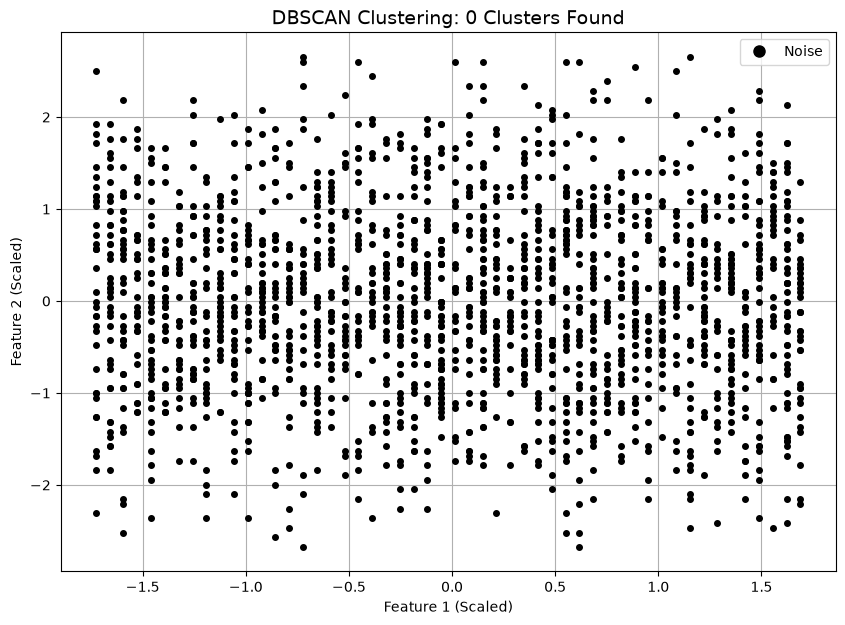

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler

# --- 1. Data Generation ---
# Generating a dataset with different shapes and noise (suitable for DBSCAN)
X=df.copy()
# --- 2. Data Preprocessing (Scaling) ---
# It's crucial to scale the data for distance-based algorithms like DBSCAN
X = StandardScaler().fit_transform(X)

# --- 3. DBSCAN Implementation ---
# Define the parameters. These were chosen based on the structure of the synthetic data.
# Epsilon (eps): max distance for two points to be neighbors
# MinPts (min_samples): minimum number of points to form a dense region
db = DBSCAN(eps=0.15, min_samples=10).fit(X)

# Extract cluster labels. Noise points are assigned a label of -1.
labels = db.labels_

# Number of clusters in labels, ignoring noise if present
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

# --- 4. Visualization of Clusters ---
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Define a color map for the clusters, with black reserved for noise
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(10, 7))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise points
        col = [0, 0, 0, 1]

    # Create a mask for points belonging to the current cluster k
    class_member_mask = (labels == k)

    # Plot core points of the cluster
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=8, label=f'Cluster {k}' if k != -1 else 'Noise')

    # Plot border points of the cluster
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=4)

plt.title(f'DBSCAN Clustering: {n_clusters_} Clusters Found', fontsize=14)
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

# --- Visualization Key ---
# Larger dots with black borders are **Core Points**.
# Smaller dots with black borders are **Border Points**.
# Black dots (label -1) are **Noise Points (Outliers)**.

Estimated number of clusters: 0
Estimated number of noise points: 1895

Cluster Distribution:
cluster
-1    1895
Name: count, dtype: int64


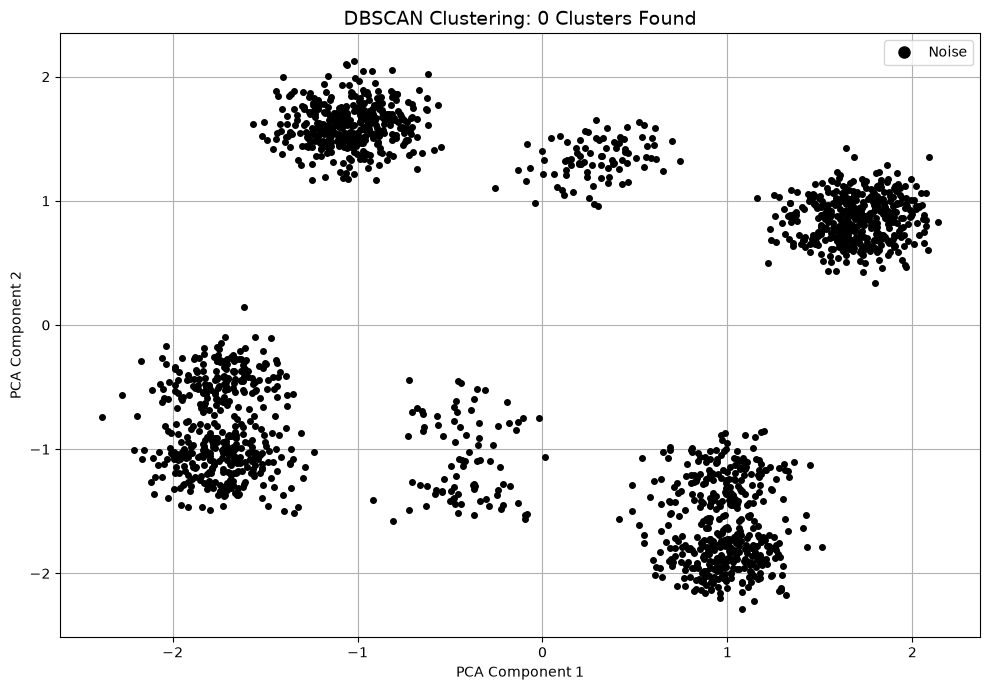

In [117]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X = df.copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



db = DBSCAN(
    eps=0.9,
    min_samples=20
)

labels = db.fit_predict(X_scaled)



n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")


df["cluster"] = labels

print("\nCluster Distribution:")
print(df["cluster"].value_counts().sort_index())


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#visualizations

unique_labels = sorted(set(labels))

plt.figure(figsize=(10, 7))

colors = [
    plt.cm.Spectral(each)
    for each in np.linspace(0, 1, len(unique_labels))
]


for cluster, color in zip(unique_labels, colors):

    # Noise
    if cluster == -1:
        color = [0, 0, 0, 1]
        label = "Noise"
    else:
        label = f"Cluster {cluster}"

    mask = labels == cluster

    # Core points
    core_mask = np.zeros_like(labels, dtype=bool)
    core_mask[db.core_sample_indices_] = True

    core_points = X_pca[mask & core_mask]

    plt.plot(
        core_points[:, 0],
        core_points[:, 1],
        "o",
        markerfacecolor=tuple(color),
        markeredgecolor="k",
        markersize=8,
        label=label
    )

    # Border points
    border_points = X_pca[mask & ~core_mask]

    plt.plot(
        border_points[:, 0],
        border_points[:, 1],
        "o",
        markerfacecolor=tuple(color),
        markeredgecolor="k",
        markersize=4
    )


plt.title(
    f"DBSCAN Clustering: {n_clusters} Clusters Found",
    fontsize=14
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()